In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import tensorflow as tf
tf.__version__

2026-03-15 06:07:10.543360: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773554830.922774      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773554831.040736      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773554832.058471      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773554832.058527      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773554832.058530      55 computation_placer.cc:177] computation placer alr

'2.19.0'

In [3]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [4]:
base_path = "/kaggle/input/cell-images-for-detecting-malaria/cell_images/cell_images"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Training — augmentation + MobileNetV2 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   
    validation_split=0.2,
    rotation_range=180,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)
train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),                    
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation — preprocessing only, NO augmentation
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # ← fixed
    validation_split=0.2
)
val_generator = val_datagen.flow_from_directory(
    base_path,
    target_size=(128, 128),                    # ← fixed
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

print(train_generator.class_indices)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.
{'Parasitized': 0, 'Uninfected': 1}


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger

callbacks = [
    ModelCheckpoint("mobilenet_malaria.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    CSVLogger("mobilenetv2_malaria_log.csv")
]

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = MobileNetV2(         
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)      
)

# Freeze base
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(train_generator.num_classes, activation="softmax")(x)

mobilenet_model = Model(inputs=base_model.input, outputs=outputs) 

I0000 00:00:1773554882.043713      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,914,882 (11.12 MB)

 Trainable params: 656,898 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total parameters : {mobilenet_model.count_params():,}")
print(f"Output classes   : {train_generator.num_classes}")

Total parameters : 2,914,882
Output classes   : 2


In [11]:
history = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15


I0000 00:00:1773554891.815254     138 service.cc:152] XLA service 0x7967fc002900 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773554891.815294     138 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773554892.950079     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773554899.438167     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.8153 - loss: 0.4129
Epoch 1: val_accuracy improved from -inf to 0.87132, saving model to mobilenet_malaria.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 339s 473ms/step - accuracy: 0.8154 - loss: 0.4128 - val_accuracy: 0.8713 - val_loss: 0.3165 - learning_rate: 1.0000e-04
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9041 - loss: 0.2460
Epoch 2: val_accuracy improved from 0.87132 to 0.88330, saving model to mobilenet_malaria.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 123s 179ms/step - accuracy: 0.9041 - loss: 0.2460 - val_accuracy: 0.8833 - val_loss: 0.2898 - learning_rate: 1.0000e-04
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.9121 - loss: 0.2270
Epoch 3: val_accuracy improved from 0.88330 to 0.89365, saving model to mobilenet_malaria.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 124s 180ms/step - accuracy: 0.9121 - loss: 0.2269 - val_accuracy: 0.8936 - val_loss: 0.2718 - learning_rate: 1.0000e-04
Epoch 4/15
689/

In [13]:
mobilenet_model.save("mobilenet_malaria.keras")

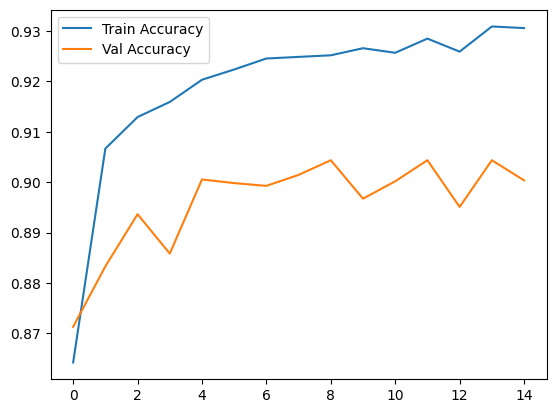

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

val_generator.reset()   # ← reset internal state

preds = mobilenet_model.predict(
    val_generator,
    steps=len(val_generator),   # ← ceil(5510 / 32) = 173 steps, no wrap-around
    verbose=1
)

pred_labels = np.argmax(preds, axis=1)
true_labels = val_generator.classes   # ground truth in order

173/173 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step


In [20]:
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2329  426]
 [ 101 2654]]


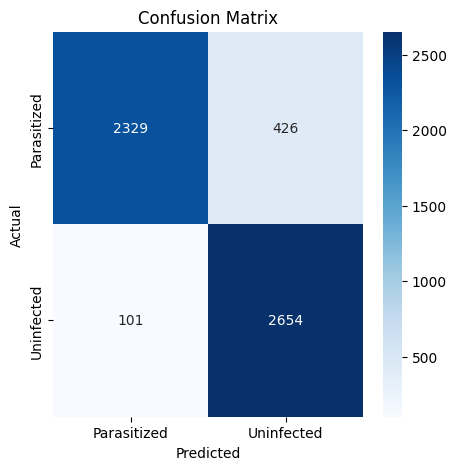

In [21]:
import seaborn as sns

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Parasitized','Uninfected'],
            yticklabels=['Parasitized','Uninfected'])

plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [22]:
print(classification_report(true_labels, pred_labels, target_names=['Parasitized','Uninfected']))

              precision    recall  f1-score   support

 Parasitized       0.96      0.85      0.90      2755
  Uninfected       0.86      0.96      0.91      2755

    accuracy                           0.90      5510
   macro avg       0.91      0.90      0.90      5510
weighted avg       0.91      0.90      0.90      5510

